In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod import families
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("ETH_day.csv")

In [5]:
EDA

NameError: name 'EDA' is not defined

In [ ]:
df.shape

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        1438 non-null   object 
 1   Symbol      1438 non-null   object 
 2   Open        1438 non-null   float64
 3   High        1438 non-null   float64
 4   Low         1438 non-null   float64
 5   Close       1438 non-null   float64
 6   Volume ETH  1438 non-null   float64
 7   Volume USD  1438 non-null   float64
dtypes: float64(6), object(2)
memory usage: 90.0+ KB


In [7]:
df.columns

Index(['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume ETH',
       'Volume USD'],
      dtype='object')

In [8]:
df.dtypes

Date           object
Symbol         object
Open          float64
High          float64
Low           float64
Close         float64
Volume ETH    float64
Volume USD    float64
dtype: object

In [9]:
df.describe()

,Open,High,Low,Close,Volume ETH,Volume USD
count,1438.000000,1438.000000,1438.000000,1438.000000,1.438000e+03,1.438000e+03
mean,239.397149,248.919200,227.681446,239.468011,3.720638e+04,1.139557e+07
std,237.662224,248.677428,222.794938,237.606382,6.908336e+04,2.143780e+07
min,6.770000,7.290000,5.990000,6.770000,0.000000e+00,0.000000e+00
25%,79.782500,84.875000,74.677500,80.732500,7.020215e+03,7.541171e+05
50%,181.430000,187.020000,175.850000,181.430000,1.780439e+04,3.221372e+06
75%,297.735000,306.015000,287.427500,297.502500,4.204451e+04,1.204918e+07
max,1381.850000,1420.010000,1270.000000,1381.850000,1.827755e+06,2.221193e+08


In [10]:
df.head()

,Date,Symbol,Open,High,Low,Close,Volume ETH,Volume USD
0,2020-04-15,ETHUSD,158.61,158.61,158.61,158.61,0.00,0.00
1,2020-04-14,ETHUSD,156.97,162.15,155.74,158.61,18061.58,2872210.44
2,2020-04-13,ETHUSD,158.56,159.51,150.12,156.97,15698.32,2416728.28
3,2020-04-12,ETHUSD,158.66,165.37,155.21,158.56,12877.33,2082804.05
4,2020-04-11,ETHUSD,158.26,161.49,154.25,158.66,13761.72,2172914.57


In [11]:
df.tail()

,Date,Symbol,Open,High,Low,Close,Volume ETH,Volume USD
1433,2016-05-13,ETHUSD,10.20,11.59,10.20,10.69,1769.71,18923.55
1434,2016-05-12,ETHUSD,10.43,12.00,9.92,10.20,2072.56,22183.39
1435,2016-05-11,ETHUSD,9.68,10.47,9.68,10.43,3052.51,30978.11
1436,2016-05-10,ETHUSD,9.98,9.98,9.36,9.68,672.06,6578.20
1437,2016-05-09,ETHUSD,12.00,12.00,9.36,9.98,1317.90,12885.06


In [12]:
df.nunique()

Date          1438
Symbol           1
Open          1351
High          1320
Low           1288
Close         1349
Volume ETH    1434
Volume USD    1434
dtype: int64

In [13]:
print(df.duplicated().sum())

0


In [14]:
print(df.isnull().sum())

Date          0
Symbol        0
Open          0
High          0
Low           0
Close         0
Volume ETH    0
Volume USD    0
dtype: int64


In [15]:
df.dropna(how='all', inplace=True)
df.drop_duplicates(inplace=True)

In [16]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

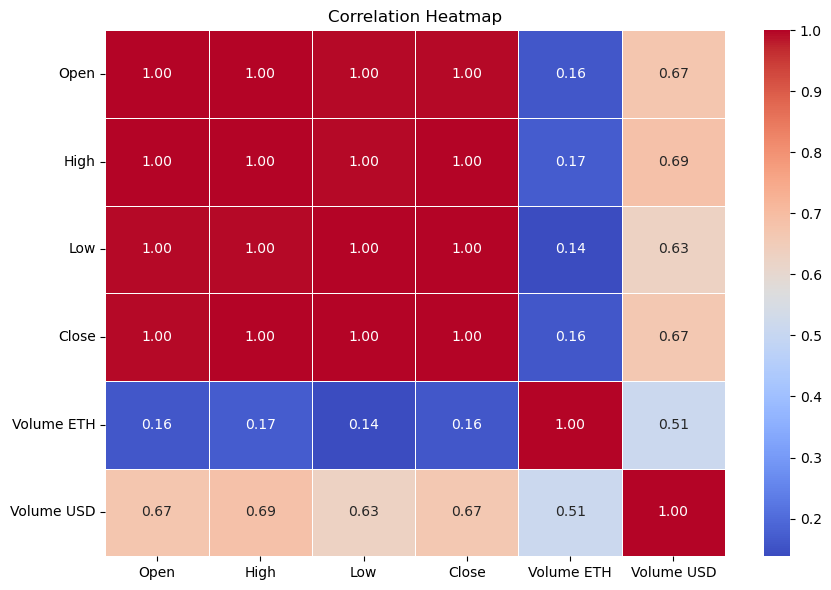

In [17]:
corr = df[['Open', 'High', 'Low', 'Close', 'Volume ETH', 'Volume USD']].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [18]:
           # Additional EDA/Advanced Preprocessing Step-------
df[['Open', 'High', 'Low', 'Close', 'Volume ETH']].skew()

Open           1.747156
High           1.787202
Low            1.674723
Close          1.748323
Volume ETH    13.260757
dtype: float64

In [19]:
          # Additional EDA/Advanced Preprocessing Step-------
df['Close_Lag1'] = df['Close'].shift(1)
print(df[['Date','Close','Close_Lag1']].head())

        Date  Close  Close_Lag1
0 2016-05-09   9.98         NaN
1 2016-05-10   9.68        9.98
2 2016-05-11  10.43        9.68
3 2016-05-12  10.20       10.43
4 2016-05-13  10.69       10.20


In [20]:
Advance Visualuization 

SyntaxError: invalid syntax (2647756335.py, line 1)

In [32]:
df_numeric = df.drop(columns=['Symbol', 'Date'])

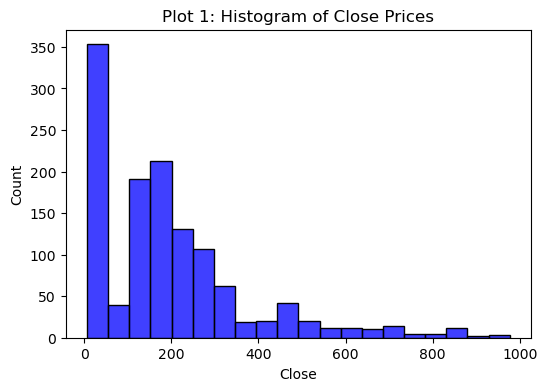

In [33]:
# Plot 1: Histogram (Shows price distributions)
plt.figure(figsize=(6, 4))
sns.histplot(df_numeric['Close'], bins=20, color='blue', kde=False)
plt.title('Plot 1: Histogram of Close Prices')
plt.show()

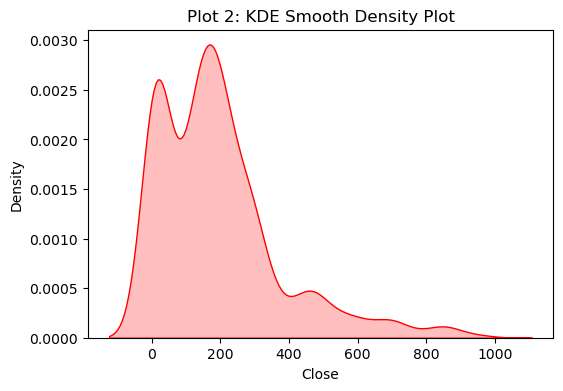

In [34]:
# Plot 2: KDE Plot (Shows the smooth density curve of prices)
plt.figure(figsize=(6, 4))
sns.kdeplot(df_numeric['Close'], color='red', fill=True)
plt.title('Plot 2: KDE Smooth Density Plot')
plt.show()

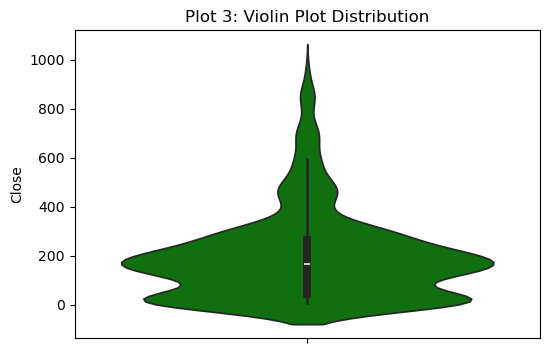

In [35]:
# Plot 3: Violin Plot (Combines a boxplot and a density plot)
plt.figure(figsize=(6, 4))
sns.violinplot(y=df_numeric['Close'], color='green')
plt.title('Plot 3: Violin Plot Distribution')
plt.show()

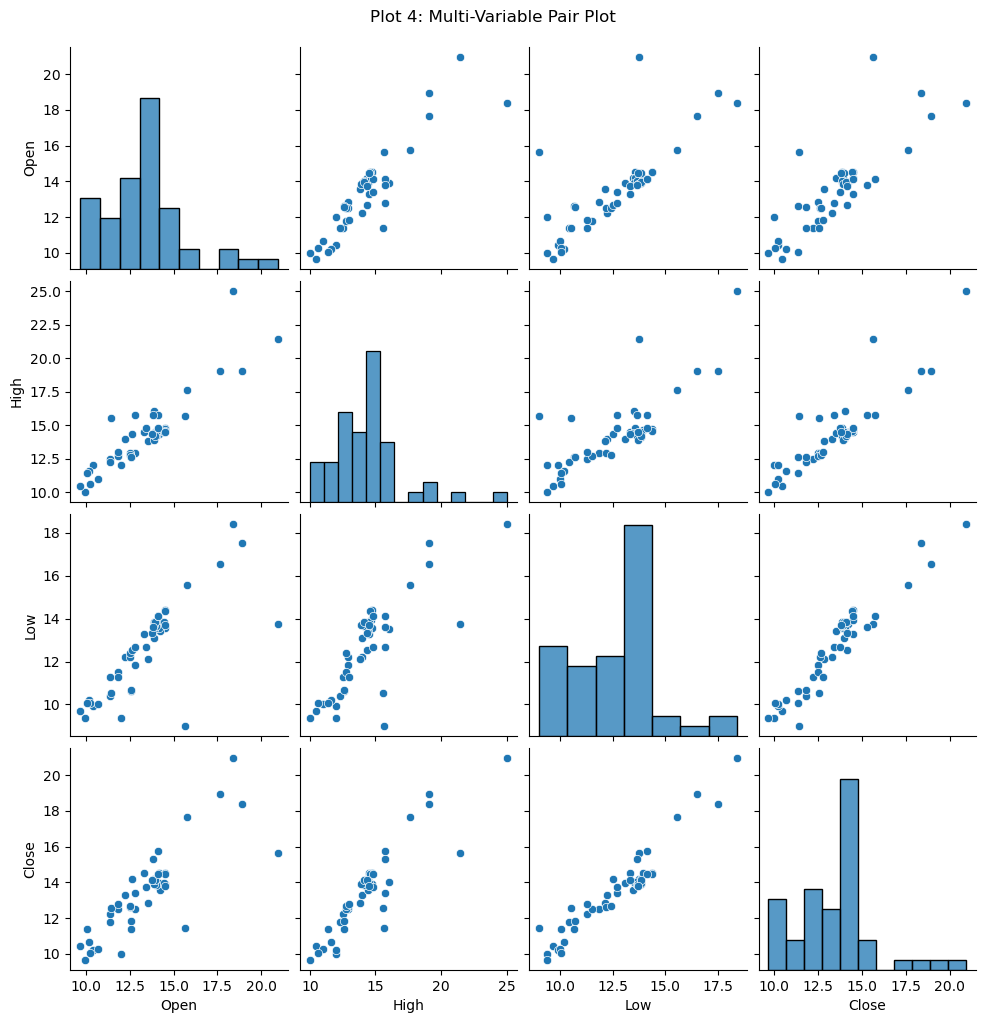

In [36]:
# Plot 4: Pair Plot (Shows relationships between multiple variables simply)
# take a small sample of 50 rows so it loads instantly without crashing
sample_df = df_numeric[['Open', 'High', 'Low', 'Close']].head(50)
sns.pairplot(sample_df)
plt.suptitle('Plot 4: Multi-Variable Pair Plot', y=1.02)
plt.show()

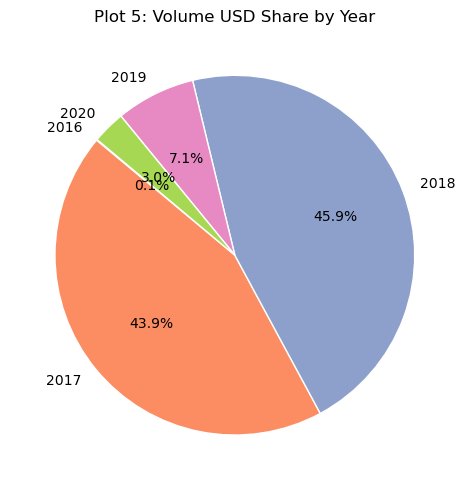

In [23]:
# Plot 5: Pie Chart (Shows data proportions simply)
# Count how many entries have high volume vs low volume to make slices
df['Year'] = df['Date'].dt.year
vol_by_year = df.groupby('Year')['Volume USD'].sum()

plt.figure(figsize=(5, 5))
plt.pie(vol_by_year, labels=vol_by_year.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2', len(vol_by_year)), startangle=140,
        wedgeprops={'edgecolor': 'white'})
plt.title('Plot 5: Volume USD Share by Year')
plt.tight_layout()
plt.show()

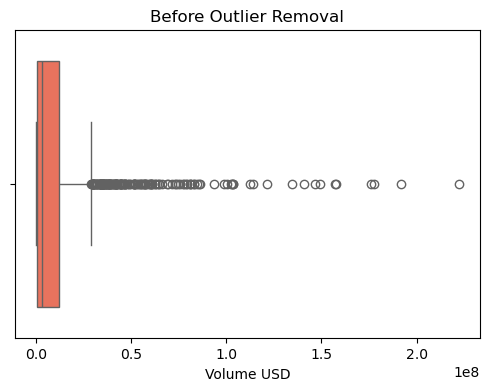

In [24]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Volume USD'], color='tomato')
plt.title('Before Outlier Removal')
plt.show()

In [40]:
# Outlier Removal via IQR 
Q1 = df['Volume USD'].quantile(0.25)
Q3 = df['Volume USD'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Volume USD'] >= lower_bound) & (df['Volume USD'] <= upper_bound)]
df = df.reset_index(drop=True)

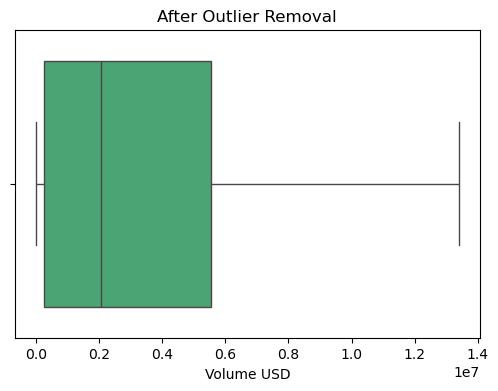

In [39]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Volume USD'], color='mediumseagreen', showfliers=False)
plt.title('After Outlier Removal')
plt.show()

In [27]:
features = ['Open', 'High', 'Low', 'Volume ETH', 'Volume USD']
X = df[features]
y = df['Close']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)
y_final = y.reset_index(drop=True)

In [28]:
#0.20 mean 20% for test 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_final, test_size=0.20, random_state=42, shuffle=False)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test : {X_test.shape[0]} samples")

Train: 1016 samples
Test : 255 samples


In [29]:
# GENERALIZED LINEAR MODEL---
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

glm_model  = GLM(y_train, X_train_sm,
                 family=families.Gaussian(link=families.links.Identity()))
glm_result = glm_model.fit()
print(glm_result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Close   No. Observations:                 1016
Model:                            GLM   Df Residuals:                     1010
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                          21.276
Method:                          IRLS   Log-Likelihood:                -2991.9
Date:                Sat, 13 Jun 2026   Deviance:                       21488.
Time:                        08:49:28   Pearson chi2:                 2.15e+04
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        194.8681      0.145   1339.705      0.0

In [30]:
y_pred = glm_result.predict(X_test_sm)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Mean Absolute Error  (MAE) : {mae:.4f}")
print(f"Mean Squared Error   (MSE) : {mse:.4f}")
print(f"Root Mean Squared    (RMSE): {rmse:.4f}")
print(f"R-squared            (R²)  : {r2:.4f}")
print(f"Mean Abs % Error     (MAPE): {mape:.4f}")

Mean Absolute Error  (MAE) : 2.0652
Mean Squared Error   (MSE) : 9.0735
Root Mean Squared    (RMSE): 3.0122
R-squared            (R²)  : 0.9929
Mean Abs % Error     (MAPE): 0.0118


In [31]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

results_df = pd.DataFrame({
    'Model' : ['GLM (Gaussian)', 'Linear Regression', 'Ridge Regression'],
    'MAE'   : [mean_absolute_error(y_test, y_pred),
               mean_absolute_error(y_test, y_pred_lr),
               mean_absolute_error(y_test, y_pred_ridge)],
    'MSE'   : [mean_squared_error(y_test, y_pred),
               mean_squared_error(y_test, y_pred_lr),
               mean_squared_error(y_test, y_pred_ridge)],
    'RMSE'  : [np.sqrt(mean_squared_error(y_test, y_pred)),
               np.sqrt(mean_squared_error(y_test, y_pred_lr)),
               np.sqrt(mean_squared_error(y_test, y_pred_ridge))],
    'R²'    : [r2_score(y_test, y_pred),
               r2_score(y_test, y_pred_lr),
               r2_score(y_test, y_pred_ridge)],
    'MAPE'  : [mean_absolute_percentage_error(y_test, y_pred),
               mean_absolute_percentage_error(y_test, y_pred_lr),
               mean_absolute_percentage_error(y_test, y_pred_ridge)]
})
print(results_df.to_string(index=False))

            Model      MAE       MSE     RMSE       R²     MAPE
   GLM (Gaussian) 2.065197  9.073500 3.012225 0.992921 0.011815
Linear Regression 2.065197  9.073500 3.012225 0.992921 0.011815
 Ridge Regression 2.518343 13.365704 3.655914 0.989572 0.014146
